Basler camera selected
Timeout of camera!
Sensor readout mode not accepted by camera, 'BaslerCamera' object has no attribute 'camera'
Basler AOI:  [0, 1936, 0, 1216]


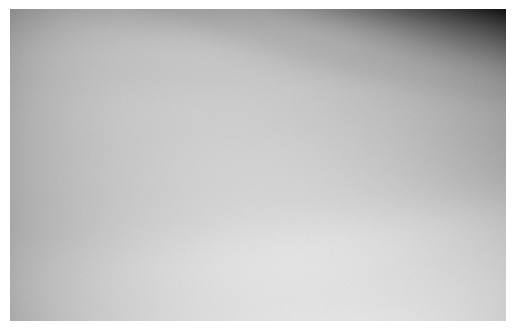

In [ ]:
### Example to test that the camera is working

# add to the path the parent directory
import matplotlib.pyplot as plt
import sys

sys.path.append('./..')

import camera_interface as ci

testmode = 0  # 0 for camera, 1 for random data

if testmode:
    from camera_controls import TestCamera
    camera = TestCamera()
    camera.connect_camera()
else:
    camera_type = "Basler"  # "Thorlabs" or "Basler"
    # In normal mode we use the camera as input
    if camera_type == "Thorlabs":
        print("Thorlabs camera selected")
        from thorlabs_scientific_cameras import ThorlabsScientificCamera as TSC
        camera = TSC()
    else:
        print("Basler camera selected")
        from basler_cameras import BaslerCamera
        camera = BaslerCamera()

# Define c_p as a dictionary if not already defined
c_p = {}
c_p['program_running'] = False

# Start camera thread
if camera is not None:
    camera_thread = ci.CameraThread(c_p, camera)
    camera_thread.start()

# acquire one frame and show it
if camera is not None:
    frame = camera.capture_image()
    if frame is not None:
        plt.imshow(frame, cmap='gray')
        plt.axis('off')
    else:
        print("No frame acquired from camera")
    if not testmode:
        camera.disconnect_camera()

else:
    print("No camera available")

# kill camera thread
if camera is not None:
    camera_thread.join()